# Catalog coverage
Measures how Western, non-Western and international catalogs and Wikipedias cover individuals across polities.

In [1]:
import random
import tempfile
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objects as go
from IPython.display import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'

INTERNATIONAL_QID = 'Q1072012'
BUCKET_YEARS = 50

COLORS = {
    'western_catalog': '#4a7fb5',
    'non_western_catalog': '#c77b58',
    'international_catalog': '#86ad6b',
    'western_wikipedia': '#b3cfe6',
    'non_western_wikipedia': '#ecc3ae',
    'both_catalogs': '#8c8c8c',
    'both_wikipedias': '#cfc9e0',
    'no_catalog_no_wiki': '#e3e3e3',
    'neutral_bar': '#6b7d8f',
}
LIGHT_COLORS = {COLORS[k] for k in ['western_wikipedia', 'non_western_wikipedia', 'both_wikipedias', 'no_catalog_no_wiki']}

CHINESE_POLITY_COLORS = {
    'Shang': '#6c2a2c', 'Zhou': '#8e4f33', 'Qin': '#b07a3f', 'Han': '#c8a472',
    'Six Dynasties': '#8e7a8a', 'Sui': '#6c8a8a', 'Tang': '#4f8a98', 'Five Dynasties': '#5b6f8e',
    'Song': '#3e5b8e', 'Yuan': '#6a4f8a', 'Ming': '#8e4f7a', 'Qing': '#a05a6a',
}

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.formatter.useoffset': False,
})

## External data — none

## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

## Load data
### Catalog categories

In [3]:
identifier_properties = con.sql('''
    WITH place_state AS (
        SELECT p.entity.qid AS qid, p.entity.label_en AS country_name,
               CASE WHEN p.present_day_state.name IS NOT NULL THEN p.present_day_state ELSE c.present_day_state END AS state
        FROM place p
        LEFT JOIN place c ON c.entity.qid = p.country.qid
    )
    SELECT i.property.pid AS pid, i.property.label_en AS identifier_name,
           i.issuer_country.name AS country_qid, s.country_name, s.state.is_western AS is_western
    FROM identifier i
    LEFT JOIN place_state s ON s.qid = i.issuer_country.name
''').pl()

assert identifier_properties['pid'].n_unique() == identifier_properties.height
print('shape:', identifier_properties.shape)
print('with issuer country:', identifier_properties['country_qid'].drop_nulls().len())
unresolved = identifier_properties.filter(pl.col('country_qid').is_not_null() & pl.col('is_western').is_null())
print('issuer countries with no present-day state in V2:')
print(unresolved.group_by('country_qid', 'country_name').len().sort('len', descending=True))
identifier_properties.drop_nulls('country_qid').head()

shape: (10198, 5)
with issuer country: 1435
issuer countries with no present-day state in V2:
shape: (5, 3)
┌─────────────┬───────────────────┬─────┐
│ country_qid ┆ country_name      ┆ len │
│ ---         ┆ ---               ┆ --- │
│ str         ┆ str               ┆ u32 │
╞═════════════╪═══════════════════╪═════╡
│ Q55         ┆ Netherlands       ┆ 25  │
│ Q1206012    ┆ German Reich      ┆ 1   │
│ Q41304      ┆ Weimar Republic   ┆ 1   │
│ Q13426199   ┆ Republic of China ┆ 1   │
│ Q1072012    ┆ null              ┆ 1   │
└─────────────┴───────────────────┴─────┘


pid,identifier_name,country_qid,country_name,is_western
str,str,str,str,bool
"""P13174""","""CamerounWeb person ID""","""Q1009""","""Cameroon""",false
"""P11019""","""Moroccan Olympic Committee ath…","""Q1028""","""Morocco""",false
"""P13699""","""National Library of Nigeria ID""","""Q1033""","""Nigeria""",false
"""P2298""","""NSDAP membership number (1925–…","""Q1206012""","""German Reich""",null
"""P13743""","""Digital ROC people ID""","""Q13426199""","""Republic of China""",null


In [4]:
catalog_categories = identifier_properties.with_columns(
    pl.when(pl.col('country_qid') == INTERNATIONAL_QID).then(pl.lit('international'))
    .when(pl.col('is_western')).then(pl.lit('western'))
    .when(~pl.col('is_western')).then(pl.lit('non_western'))
    .otherwise(None)
    .alias('category')
)

catalog_categories.group_by('category').len().sort('len', descending=True)

category,len
str,u32
null,8791
"""western""",1013
"""non_western""",393
"""international""",1


### Wikipedia categories

In [5]:
wikipedia_categories = con.sql('''
    SELECT url AS site_url,
           regexp_extract(url, 'https://([^.]+)\\.wikipedia\\.org', 1) AS language,
           CASE WHEN is_western THEN 'western' WHEN NOT is_western THEN 'non_western' END AS category
    FROM sitelink
    WHERE url LIKE '%.wikipedia.org'
''').pl()

print('shape:', wikipedia_categories.shape)
print(wikipedia_categories.group_by('category').len().sort('len', descending=True))
wikipedia_categories.drop_nulls('category').sample(5, seed=SEED)

shape: (347, 3)
shape: (3, 2)
┌─────────────┬─────┐
│ category    ┆ len │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ null        ┆ 174 │
│ non_western ┆ 98  │
│ western     ┆ 75  │
└─────────────┴─────┘


site_url,language,category
str,str,str
"""https://zu.wikipedia.org""","""zu""","""non_western"""
"""https://he.wikipedia.org""","""he""","""non_western"""
"""https://yi.wikipedia.org""","""yi""","""non_western"""
"""https://ro.wikipedia.org""","""ro""","""western"""
"""https://sr.wikipedia.org""","""sr""","""western"""


### Catalog and Wikipedia flags

In [6]:
con.register('catalog_categories_df', catalog_categories.drop_nulls('category').select('pid', 'category'))
con.register('wikipedia_categories_df', wikipedia_categories.drop_nulls('category').select('site_url', 'category'))

con.sql('''
    CREATE OR REPLACE TEMP TABLE catalog_flags AS
    SELECT ii.qid,
           bool_or(c.category = 'western')       AS has_western_catalog,
           bool_or(c.category = 'non_western')   AS has_non_western_catalog,
           bool_or(c.category = 'international') AS has_international_catalog
    FROM individual_identifier ii
    JOIN catalog_categories_df c USING (pid)
    GROUP BY ii.qid
''')

con.sql('''
    CREATE OR REPLACE TEMP TABLE wikipedia_flags AS
    SELECT s.qid,
           bool_or(w.category = 'western')     AS has_western_wikipedia,
           bool_or(w.category = 'non_western') AS has_non_western_wikipedia
    FROM individual_sitelink s
    JOIN wikipedia_categories_df w USING (site_url)
    GROUP BY s.qid
''')

for table in ['catalog_flags', 'wikipedia_flags']:
    n, n_unique = con.sql(f'SELECT COUNT(*), COUNT(DISTINCT qid) FROM {table}').fetchone()
    assert n == n_unique
    print(f'{table}: {n:,} individuals')
con.sql('SELECT * FROM catalog_flags USING SAMPLE reservoir(5 ROWS) REPEATABLE (42)').pl()

catalog_flags: 5,428,567 individuals
wikipedia_flags: 4,714,531 individuals


qid,has_western_catalog,has_non_western_catalog,has_international_catalog
str,bool,bool,bool
"""Q109876981""",true,false,false
"""Q111577086""",false,true,false
"""Q110165347""",true,false,false
"""Q124341353""",true,false,false
"""Q133722064""",true,false,false


### Polity matches and coverage labels

In [7]:
con.sql('''
    CREATE OR REPLACE TEMP TABLE polity_matches AS
    SELECT entity.qid AS qid, unnest(polity).polity.name AS polity_name
    FROM individual_enriched
    WHERE polity_count > 0
''')

con.sql('''
    CREATE OR REPLACE TEMP TABLE individual_coverage AS
    WITH f AS (
        SELECT e.entity.qid AS qid,
               e.peak_productivity.start_year AS window_start,
               i.birth_date[1].year AS birth_year,
               COALESCE(c.has_western_catalog, false)       AS wc,
               COALESCE(c.has_non_western_catalog, false)   AS nwc,
               COALESCE(c.has_international_catalog, false) AS ic,
               COALESCE(w.has_western_wikipedia, false)     AS ww,
               COALESCE(w.has_non_western_wikipedia, false) AS nww
        FROM individual_enriched e
        JOIN individual i ON i.entity.qid = e.entity.qid
        LEFT JOIN catalog_flags c ON c.qid = e.entity.qid
        LEFT JOIN wikipedia_flags w ON w.qid = e.entity.qid
        WHERE e.polity_count > 0
    )
    SELECT qid, window_start, birth_year,
           wc OR ww AS any_western, nwc OR nww AS any_non_western,
           CASE
               WHEN wc AND NOT nwc THEN 'western_catalog_only'
               WHEN nwc AND NOT wc THEN 'non_western_catalog_only'
               WHEN wc AND nwc     THEN 'both_catalogs'
               WHEN ic             THEN 'international_only'
               WHEN ww AND NOT nww THEN 'western_wikipedia_only'
               WHEN nww AND NOT ww THEN 'non_western_wikipedia_only'
               WHEN ww AND nww     THEN 'both_wikipedias'
               ELSE 'no_catalog_no_wikipedia'
           END AS coverage
    FROM f
''')

n_matches, n_matched = con.sql('SELECT COUNT(*), COUNT(DISTINCT qid) FROM polity_matches').fetchone()
n_coverage = con.sql('SELECT COUNT(*) FROM individual_coverage').fetchone()[0]
assert n_coverage == n_matched
print(f'polity matches: {n_matches:,} rows, {n_matched:,} individuals')
con.sql('SELECT * FROM individual_coverage USING SAMPLE reservoir(5 ROWS) REPEATABLE (42)').pl()

polity matches: 7,579,747 rows, 5,158,972 individuals


qid,window_start,birth_year,any_western,any_non_western,coverage
str,i64,i64,bool,bool,str
"""Q101252549""",1909,1880,true,false,"""western_wikipedia_only"""
"""Q112255740""",2003,1974,true,false,"""western_catalog_only"""
"""Q109251932""",1659,1630,false,false,"""no_catalog_no_wikipedia"""
"""Q115736594""",1938,1909,false,false,"""no_catalog_no_wikipedia"""
"""Q106913461""",2009,1980,true,false,"""western_catalog_only"""


### Coverage per polity

In [8]:
polity_coverage_long = con.sql('''
    SELECT m.polity_name, c.coverage, COUNT(*) AS n
    FROM polity_matches m
    JOIN individual_coverage c USING (qid)
    GROUP BY ALL
''').pl()

assert polity_coverage_long['n'].sum() == n_matches
polity_coverage_long.head()

polity_name,coverage,n
str,str,i64
"""Russian Empire""","""western_wikipedia_only""",9809
"""Union of Soviet Socialist Repu…","""non_western_wikipedia_only""",96618
"""Kingdom of England""","""western_wikipedia_only""",1235
"""Federated Republic of Germany""","""western_catalog_only""",126470
"""British Colonial Empire""","""western_catalog_only""",21109


### Coverage before vs after 1900

In [9]:
SPLIT_YEAR = 1900

period_coverage_long = con.sql(f'''
    SELECT CASE WHEN window_start < {SPLIT_YEAR} THEN 'Before 1900' ELSE 'After 1900' END AS period,
           coverage, COUNT(*) AS n
    FROM individual_coverage
    WHERE window_start IS NOT NULL
    GROUP BY ALL
''').pl()

period_coverage_long.head()

period,coverage,n
str,str,i64
"""Before 1900""","""non_western_catalog_only""",9839
"""After 1900""","""both_wikipedias""",358494
"""Before 1900""","""western_wikipedia_only""",135205
"""Before 1900""","""western_catalog_only""",496706
"""Before 1900""","""non_western_wikipedia_only""",55849


### Exclusive coverage by birth year

In [10]:
PANEL_POLITIES = ['Japan', 'Union of Soviet Socialist Republics', 'Republic of Korea', 'Republic of Turkey']
BIRTH_YEAR_MIN, BIRTH_YEAR_MAX = 1700, 2025

panel_counts = con.sql(f'''
    SELECT m.polity_name,
           CAST(FLOOR(c.birth_year / {BUCKET_YEARS}) * {BUCKET_YEARS} AS INTEGER) AS bucket,
           CASE WHEN any_western AND NOT any_non_western THEN 'Western only'
                WHEN any_non_western AND NOT any_western THEN 'Non-Western only'
                ELSE 'other' END AS exclusive_group,
           COUNT(*) AS n
    FROM polity_matches m
    JOIN individual_coverage c USING (qid)
    WHERE list_contains($panel, m.polity_name)
      AND c.birth_year > {BIRTH_YEAR_MIN} AND c.birth_year <= {BIRTH_YEAR_MAX}
    GROUP BY ALL
''', params={'panel': PANEL_POLITIES}).pl()

print('shape:', panel_counts.shape)
panel_counts.head()

shape: (66, 4)


polity_name,bucket,exclusive_group,n
str,i32,str,i64
"""Japan""",1950,"""Western only""",2661
"""Union of Soviet Socialist Repu…",1900,"""Western only""",74426
"""Japan""",1900,"""Non-Western only""",25116
"""Union of Soviet Socialist Repu…",1850,"""Western only""",17920
"""Union of Soviet Socialist Repu…",1950,"""other""",24695


### Catalog names for Figs 3 and 5

In [11]:
TANG_ROMAN_POLITIES = ['Tang Dynasty', 'Roman Empire']
POLITY_TO_MAIN_CHINESE = {
    'Shang Dynasty': 'Shang', 'Zhou Dynasty': 'Zhou', 'Qin Dynasty': 'Qin',
    'Han Dynasty': 'Han', 'Xin Dynasty': 'Han',
    'Western Jin': 'Six Dynasties', 'Liu Song Dynasty': 'Six Dynasties', 'Liang Dynasty': 'Six Dynasties',
    'Chen Dynasty': 'Six Dynasties', 'Northern Wei': 'Six Dynasties', 'Eastern Wei': 'Six Dynasties',
    'Western Wei': 'Six Dynasties', 'Northern Zhou': 'Six Dynasties', 'Northern Qi': 'Six Dynasties',
    'Sui Dynasty': 'Sui', 'Tang Dynasty': 'Tang',
    'Five Dynasties and Ten Kingdoms': 'Five Dynasties', 'Liao Dynasty': 'Five Dynasties', 'Western Xia': 'Five Dynasties',
    'Northern Song': 'Song', 'Southern Song': 'Song',
    'Yuan Dynasty': 'Yuan', 'Ming Dynasty': 'Ming', 'Qing Dynasty': 'Qing',
}
target_polities = sorted(set(TANG_ROMAN_POLITIES) | set(POLITY_TO_MAIN_CHINESE))

con.register('catalog_names_df', catalog_categories.select('pid', 'identifier_name', 'country_name'))
catalog_names = con.sql('''
    SELECT DISTINCT m.qid, m.polity_name, t.identifier_name, t.country_name AS catalog_country
    FROM polity_matches m
    JOIN individual_identifier ii USING (qid)
    JOIN catalog_names_df t USING (pid)
    WHERE list_contains($targets, m.polity_name) AND t.identifier_name IS NOT NULL
''', params={'targets': target_polities}).pl()

con.close()
print('shape:', catalog_names.shape)
catalog_names.head()

shape: (127481, 4)


qid,polity_name,identifier_name,catalog_country
str,str,str,str
"""Q10899639""","""Ming Dynasty""","""Google Knowledge Graph ID""",null
"""Q10899699""","""Qing Dynasty""","""Google Knowledge Graph ID""",null
"""Q10900211""","""Qing Dynasty""","""Google Knowledge Graph ID""",null
"""Q10916341""","""Ming Dynasty""","""Encyclopedia of China (Third E…","""People's Republic of China"""
"""Q10900291""","""Northern Song""","""Dharma Drum Institute of Liber…","""Taiwan"""


## Preprocessing

### Fig 1 data — Non-Western-only share

In [12]:
COVERAGE_SEGMENTS = [
    ('Western catalogs only', 'western_catalog_only', COLORS['western_catalog']),
    ('Western Wikipedia only', 'western_wikipedia_only', COLORS['western_wikipedia']),
    ('Non-Western catalogs only', 'non_western_catalog_only', COLORS['non_western_catalog']),
    ('Non-Western Wikipedia only', 'non_western_wikipedia_only', COLORS['non_western_wikipedia']),
    ('Both Western and Non-Western catalogs', 'both_catalogs', COLORS['both_catalogs']),
    ('Both Western and Non-Western Wikipedia', 'both_wikipedias', COLORS['both_wikipedias']),
    ('International catalogs only', 'international_only', COLORS['international_catalog']),
    ('No catalogs nor Wikipedia', 'no_catalog_no_wikipedia', COLORS['no_catalog_no_wiki']),
]
COVERAGE_COLUMNS = [column for _, column, _ in COVERAGE_SEGMENTS]
MIN_INDIVIDUALS_PER_POLITY = 2000

def to_wide(long, index):
    wide = long.pivot(values='n', index=index, on='coverage', aggregate_function='sum').fill_null(0)
    missing = [pl.lit(0).alias(c) for c in COVERAGE_COLUMNS if c not in wide.columns]
    return wide.with_columns(missing).with_columns(pl.sum_horizontal(COVERAGE_COLUMNS).alias('total_individuals'))

polity_coverage = to_wide(polity_coverage_long, 'polity_name')
print('polities before filter:', polity_coverage.height)
polity_coverage = (
    polity_coverage
    .filter(pl.col('total_individuals') >= MIN_INDIVIDUALS_PER_POLITY)
    .with_columns((pl.col('non_western_catalog_only') / pl.col('total_individuals')).alias('non_western_share'))
)
print('polities after filter: ', polity_coverage.height)

top10_polities_by_non_western = polity_coverage.sort('non_western_share', descending=True).head(10)
top10_polities_by_non_western.select('polity_name', 'total_individuals', 'non_western_catalog_only', 'non_western_share')

polities before filter: 1437
polities after filter:  232


polity_name,total_individuals,non_western_catalog_only,non_western_share
str,i64,i64,f64
"""Oriental Republic of Uruguay""",16181,8041,0.496941
"""Tanzania""",2127,534,0.251058
"""Republic of Indonesia""",78815,19572,0.248328
"""Kingdom of Lithuania""",2360,536,0.227119
"""Russian Federation""",88644,16287,0.183735
"""Republic of Iraq""",2118,349,0.164778
"""Iraqi Republic""",4684,758,0.161827
"""Republic of Belarus""",10838,1727,0.159347
"""Empire of Japan""",47499,7461,0.157077


### Fig 2 data — before vs after 1900

In [13]:
period_coverage = to_wide(period_coverage_long, 'period')
period_coverage.select('period', 'total_individuals', *COVERAGE_COLUMNS[:4])

period,total_individuals,western_catalog_only,western_wikipedia_only,non_western_catalog_only,non_western_wikipedia_only
str,i64,i64,i64,i64,i64
"""Before 1900""",990505,496706,135205,9839,55849
"""After 1900""",4168467,1585925,567333,160685,281768


### Fig 3 data — top catalogs, Tang vs Rome

In [14]:
def top10_catalogs_for_polity(polity):
    return (
        catalog_names
        .filter(pl.col('polity_name') == polity)
        .group_by('identifier_name', 'catalog_country')
        .agg(pl.col('qid').n_unique().alias('individual_count'))
        .sort('individual_count', 'identifier_name', descending=[True, False])
        .head(10)
    )

top_catalogs_by_polity = {polity: top10_catalogs_for_polity(polity) for polity in TANG_ROMAN_POLITIES}
for polity, frame in top_catalogs_by_polity.items():
    print(polity)
    print(frame)

Tang Dynasty
shape: (10, 3)
┌─────────────────────────────────┬────────────────────────────┬──────────────────┐
│ identifier_name                 ┆ catalog_country            ┆ individual_count │
│ ---                             ┆ ---                        ┆ ---              │
│ str                             ┆ str                        ┆ u32              │
╞═════════════════════════════════╪════════════════════════════╪══════════════════╡
│ Geni.com profile ID             ┆ null                       ┆ 4977             │
│ Google Knowledge Graph ID       ┆ null                       ┆ 946              │
│ Yale LUX ID                     ┆ null                       ┆ 747              │
│ VIAF cluster ID                 ┆ null                       ┆ 400              │
│ Library of Congress authority … ┆ United States              ┆ 307              │
│ Encyclopedia of China (Third E… ┆ People's Republic of China ┆ 286              │
│ WorldCat Entities ID            ┆ null        

### Fig 4 data — 50-year birth buckets

In [15]:
last_complete_bucket = (BIRTH_YEAR_MAX + 1) // BUCKET_YEARS * BUCKET_YEARS - BUCKET_YEARS
print('rows before filter:', panel_counts.height)
four_polity_panel = (
    panel_counts
    .filter(pl.col('exclusive_group') != 'other')
    .filter(pl.col('bucket') <= last_complete_bucket)
    .pivot(values='n', index=['polity_name', 'bucket'], on='exclusive_group', aggregate_function='sum')
    .fill_null(0)
    .sort('polity_name', 'bucket')
)
print('rows after filter: ', four_polity_panel.height)
four_polity_panel.head()

rows before filter: 66
rows after filter:  18


polity_name,bucket,Western only,Non-Western only
str,i32,i64,i64
"""Japan""",1850,3,24
"""Japan""",1900,1173,25116
"""Japan""",1950,2661,42396
"""Republic of Korea""",1700,0,1
"""Republic of Korea""",1750,0,1


### Fig 5 data — Sankey flows

In [16]:
MAIN_CHINESE_ORDER = list(CHINESE_POLITY_COLORS)
TOP_N_CATALOGS = 12
MIN_RIBBON_SIZE = 5
WIKI_NAME_PATTERN = '(?i)wikipedia|wikidata|wikimedia|wikisource'

chinese_individual_catalog_polity = (
    catalog_names
    .filter(pl.col('polity_name').is_in(list(POLITY_TO_MAIN_CHINESE)))
    .filter(~pl.col('identifier_name').str.contains(WIKI_NAME_PATTERN))
    .with_columns(pl.col('polity_name').replace_strict(POLITY_TO_MAIN_CHINESE).alias('main_polity'))
    .select('qid', 'identifier_name', 'main_polity')
    .unique()
)

top_catalogs = (
    chinese_individual_catalog_polity
    .group_by('identifier_name')
    .agg(pl.col('qid').n_unique().alias('individual_count'))
    .sort('individual_count', 'identifier_name', descending=[True, False])
    .head(TOP_N_CATALOGS)['identifier_name'].to_list()
)
CATALOG_ORDER = top_catalogs + ['Other catalogs']

sankey_flows = (
    chinese_individual_catalog_polity
    .with_columns(
        pl.when(pl.col('identifier_name').is_in(top_catalogs)).then(pl.col('identifier_name'))
        .otherwise(pl.lit('Other catalogs')).alias('catalog_group')
    )
    .group_by('catalog_group', 'main_polity')
    .agg(pl.col('qid').n_unique().alias('individual_count'))
    .filter(pl.col('individual_count') >= MIN_RIBBON_SIZE)
    .sort('catalog_group', 'main_polity')
)

print('chinese_individual_catalog_polity shape:', chinese_individual_catalog_polity.shape)
print('sankey_flows shape:', sankey_flows.shape)
sankey_flows.head()

chinese_individual_catalog_polity shape: (93330, 3)
sankey_flows shape: (122, 3)


catalog_group,main_polity,individual_count
str,str,u32
"""Encyclopedia of China (Third E…","""Five Dynasties""",107
"""Encyclopedia of China (Third E…","""Han""",181
"""Encyclopedia of China (Third E…","""Ming""",357
"""Encyclopedia of China (Third E…","""Qin""",13
"""Encyclopedia of China (Third E…","""Qing""",806


## Figures

### Fig 1 — Top 10 polities by Non-Western-only share

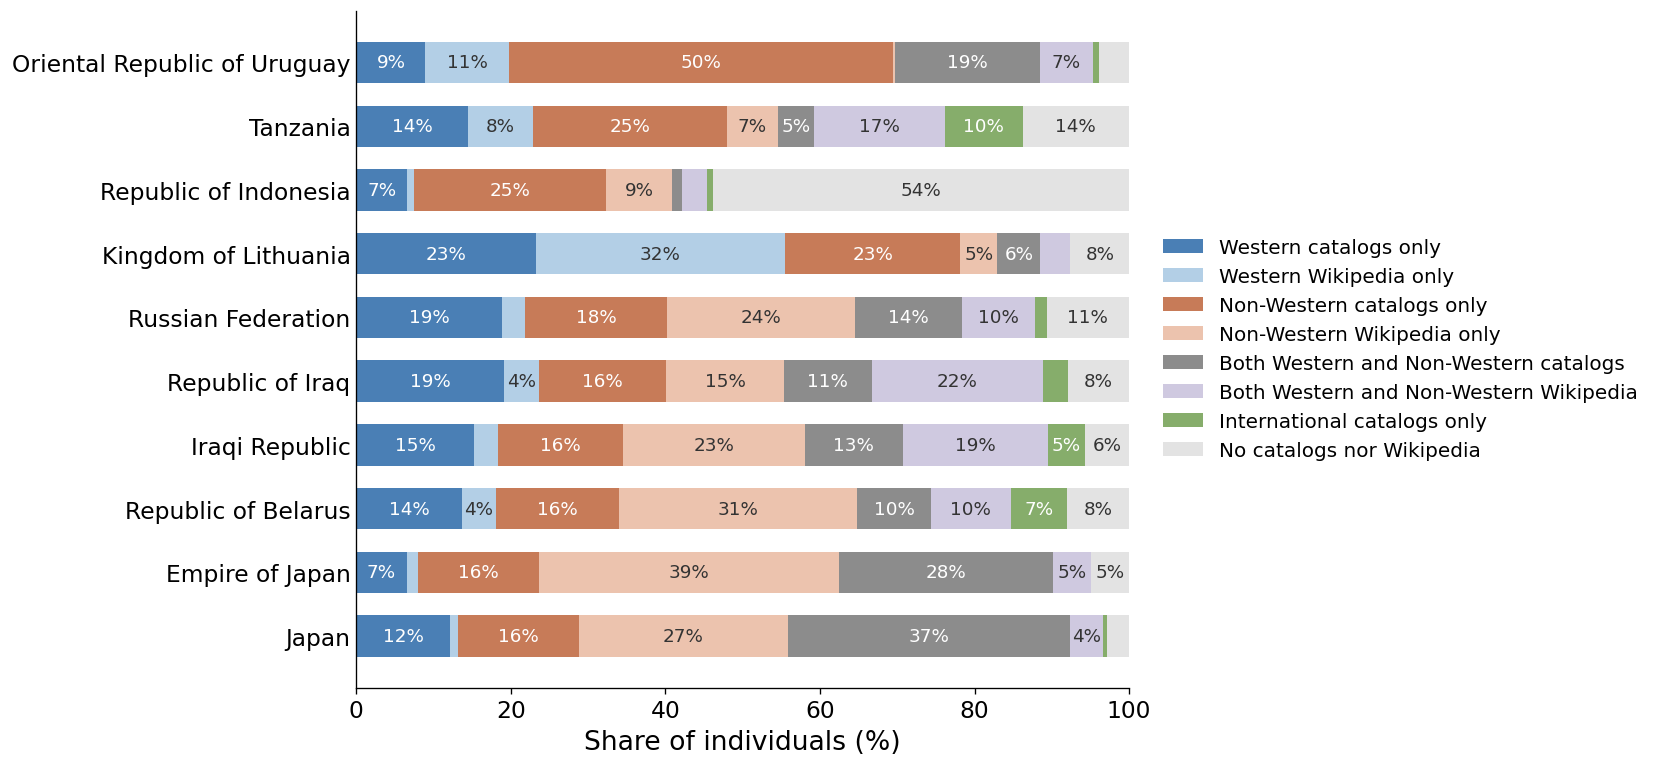

In [17]:
LABEL_THRESHOLD_PERCENT = 4.0

bottom_up = top10_polities_by_non_western.reverse()
totals = bottom_up['total_individuals'].to_numpy()
y_positions = np.arange(bottom_up.height)
left_edges = np.zeros(bottom_up.height)

fig, ax = plt.subplots(figsize=(14, 6.5))
for segment_label, column, color in COVERAGE_SEGMENTS:
    percent_values = bottom_up[column].to_numpy() / totals * 100
    ax.barh(y_positions, percent_values, height=0.65, left=left_edges, color=color, label=segment_label)
    for y, value, left_edge in zip(y_positions, percent_values, left_edges):
        if value >= LABEL_THRESHOLD_PERCENT:
            ax.text(left_edge + value / 2, y, f'{value:.0f}%', ha='center', va='center', fontsize=11,
                    color='#333333' if color in LIGHT_COLORS else 'white')
    left_edges += percent_values

ax.set_yticks(y_positions)
ax.set_yticklabels(bottom_up['polity_name'].to_list())
ax.set_xlabel('Share of individuals (%)')
ax.set_xlim(0, 100)
ax.tick_params(axis='y', length=0)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

### Fig 2 — Coverage before vs after 1900

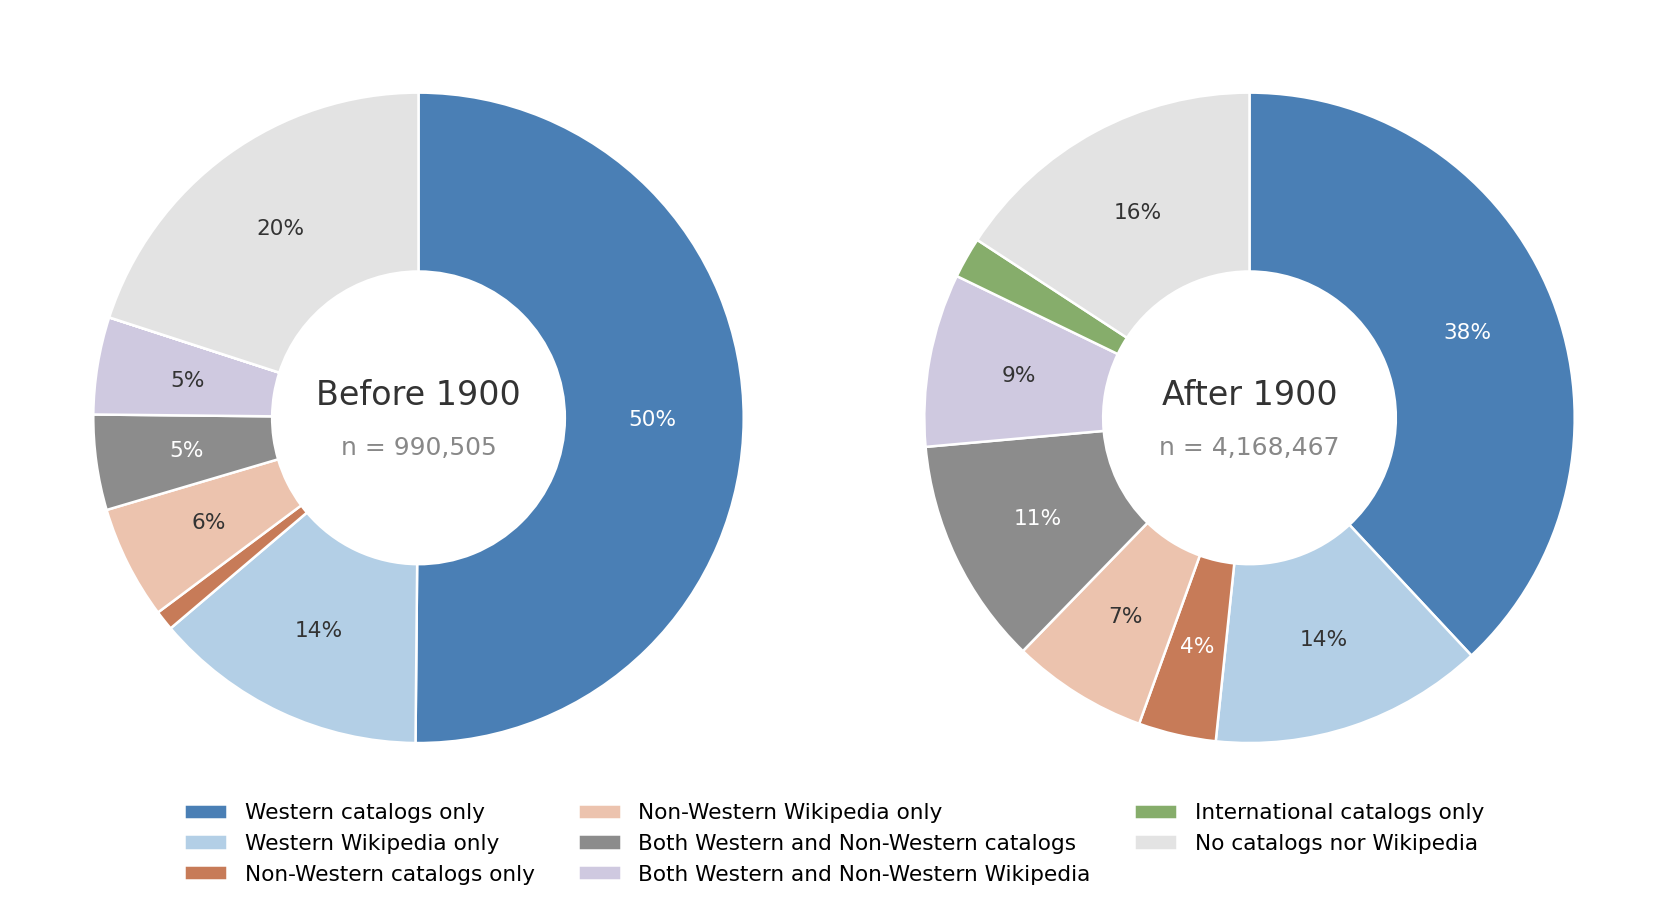

In [18]:
def percent_or_blank(percent):
    return f'{percent:.0f}%' if percent >= 3 else ''

fig, axes = plt.subplots(1, 2, figsize=(14, 7.5))
for ax, period_label in zip(axes, ['Before 1900', 'After 1900']):
    row = period_coverage.filter(pl.col('period') == period_label).row(0, named=True)
    values = [row[column] for column in COVERAGE_COLUMNS]
    colors = [color for _, _, color in COVERAGE_SEGMENTS]
    wedges, _, autotexts = ax.pie(
        values, colors=colors, autopct=percent_or_blank, pctdistance=0.72, startangle=90, counterclock=False,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    )
    for autotext, color in zip(autotexts, colors):
        autotext.set_fontsize(13)
        autotext.set_color('#333333' if color in LIGHT_COLORS else 'white')
    ax.text(0, 0.07, period_label, ha='center', va='center', fontsize=20, color='#333333')
    ax.text(0, -0.09, f"n = {row['total_individuals']:,}", ha='center', va='center', fontsize=15, color='#888888')

fig.legend(wedges, [label for label, _, _ in COVERAGE_SEGMENTS], loc='lower center', ncol=3,
           fontsize=13, frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

### Fig 3 — Top 10 catalogs: Tang vs Rome

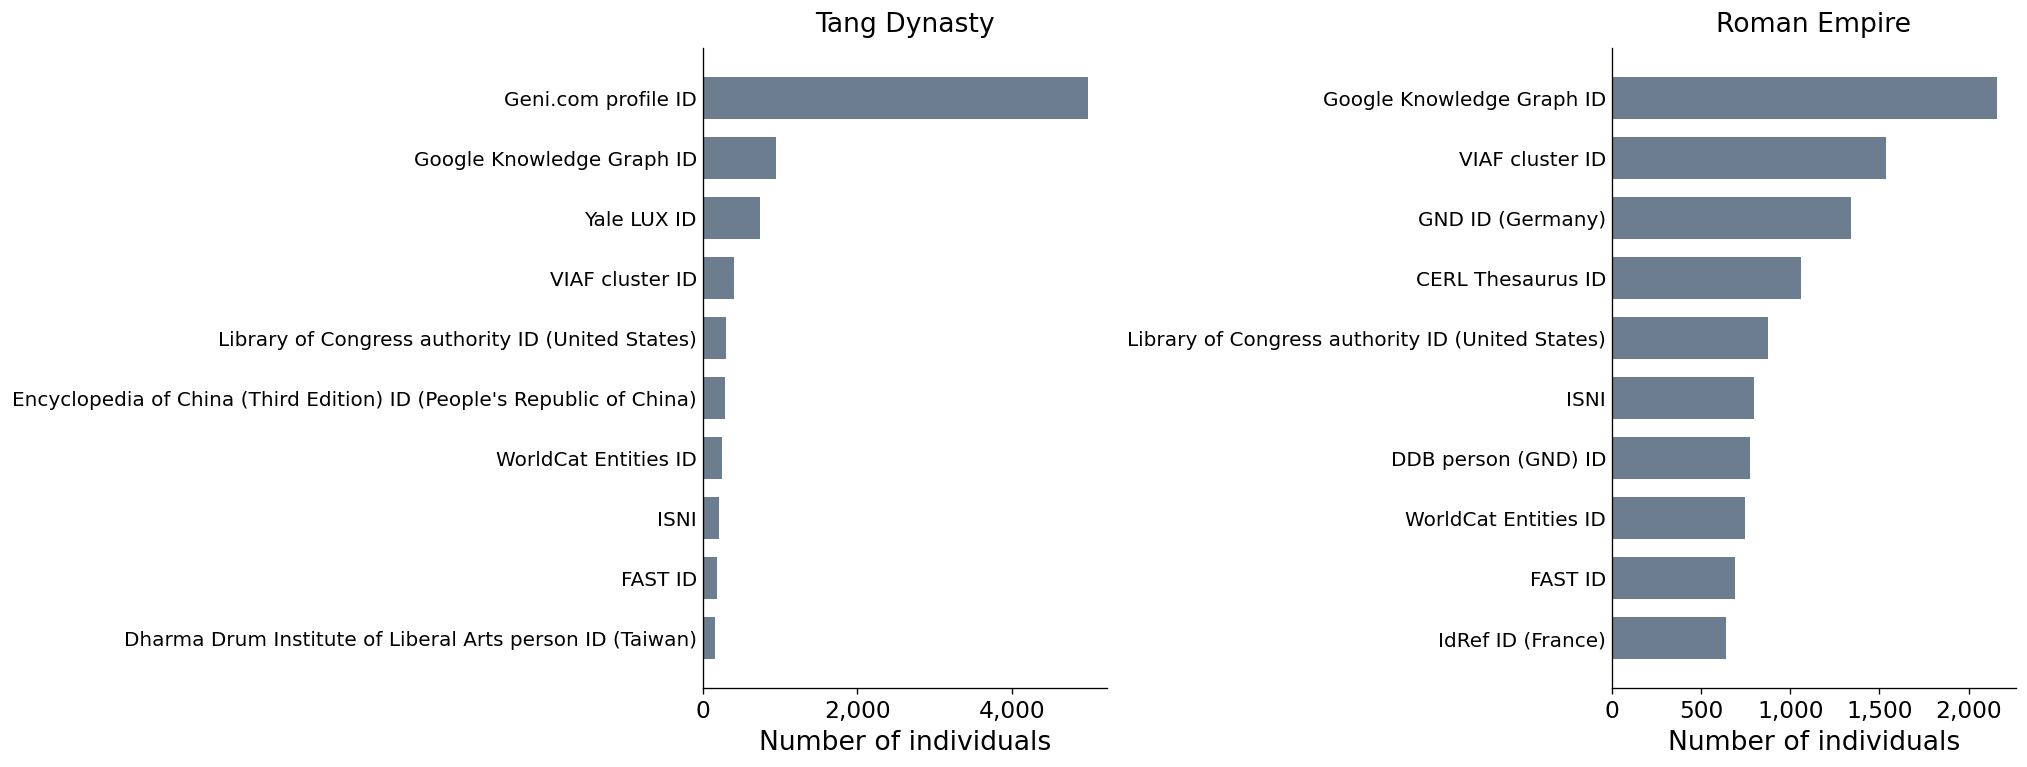

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, (polity, frame) in zip(axes, top_catalogs_by_polity.items()):
    rows = frame.reverse()
    labels = [f'{name} ({country})' if country else name for name, country in zip(rows['identifier_name'], rows['catalog_country'])]
    ax.barh(np.arange(rows.height), rows['individual_count'], height=0.7, color=COLORS['neutral_bar'])
    ax.set_yticks(np.arange(rows.height))
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel('Number of individuals')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='y', length=0)
    ax.set_title(polity, color='black', pad=10)
plt.tight_layout()
plt.show()

### Fig 4 — Exclusive coverage by birth bucket

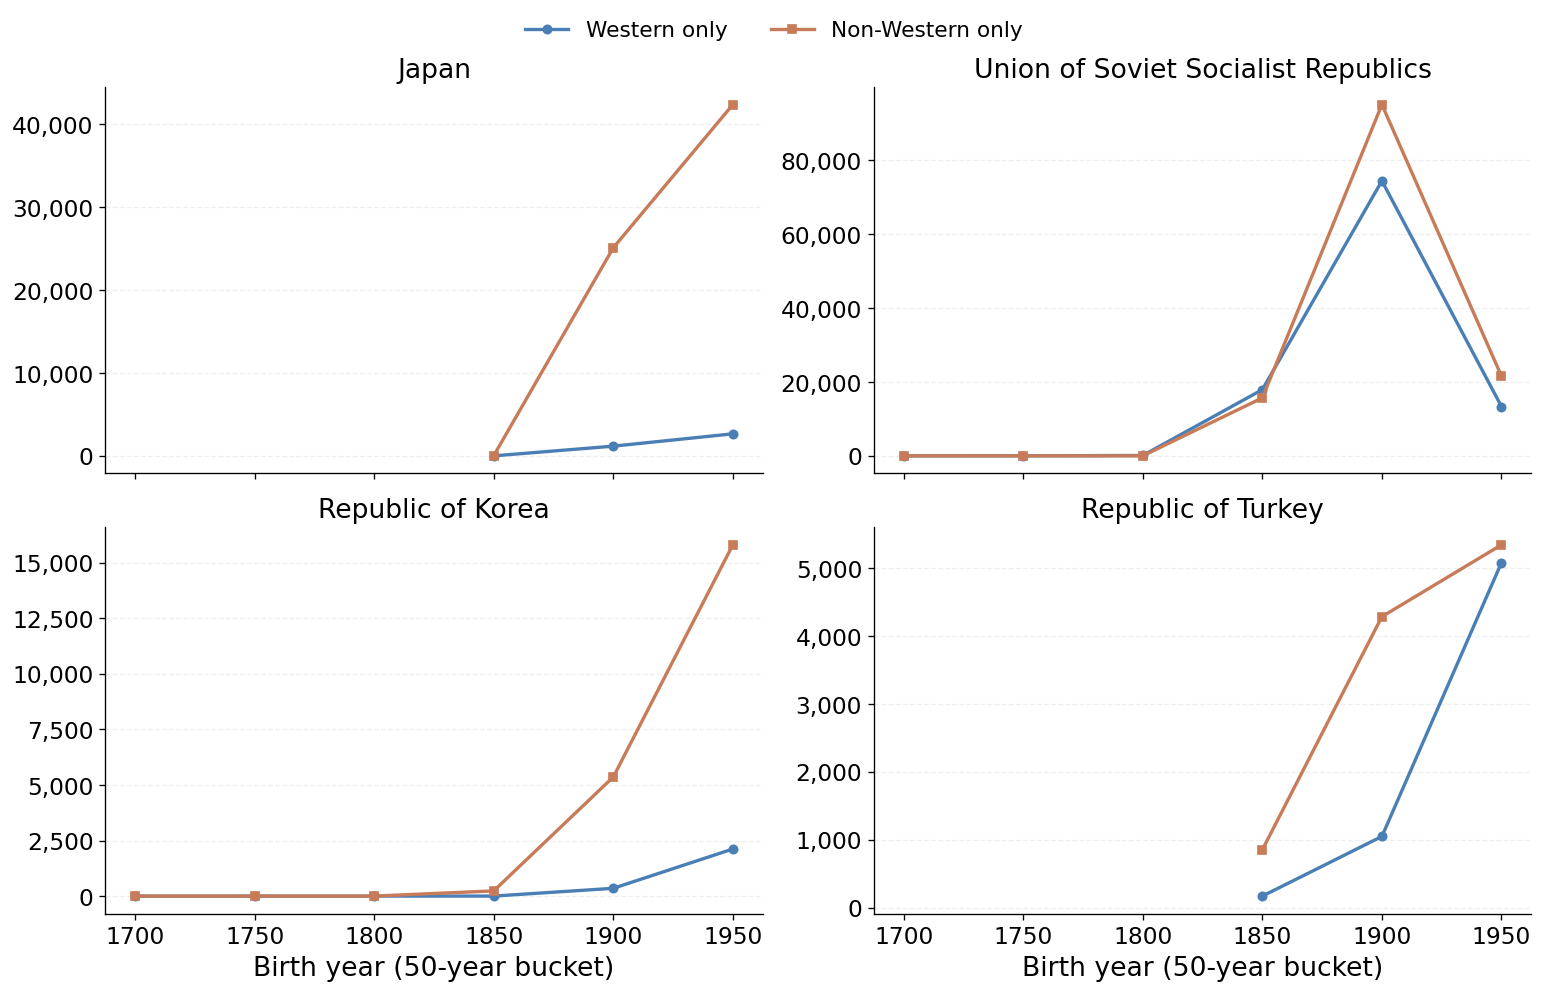

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, polity in zip(axes.flat, PANEL_POLITIES):
    rows = four_polity_panel.filter(pl.col('polity_name') == polity)
    ax.plot(rows['bucket'], rows['Western only'], color=COLORS['western_catalog'], lw=2, marker='o', ms=5, label='Western only')
    ax.plot(rows['bucket'], rows['Non-Western only'], color=COLORS['non_western_catalog'], lw=2, marker='s', ms=5, label='Non-Western only')
    ax.set_title(polity, color='black')
    ax.grid(axis='y', alpha=0.2, ls='--')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
for ax in axes[-1, :]:
    ax.set_xlabel('Birth year (50-year bucket)')
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.tight_layout()
plt.show()

### Fig 5 — Catalogs → Chinese polities

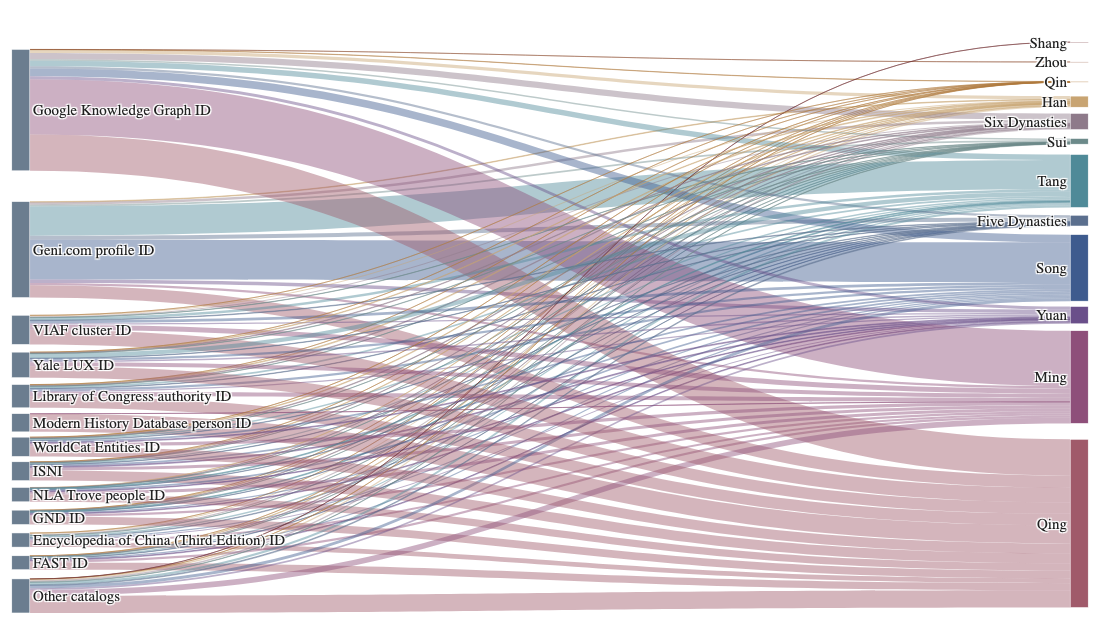

In [21]:
def hex_to_rgba(hex_color, alpha):
    r, g, b = (int(hex_color.lstrip('#')[i:i + 2], 16) for i in (0, 2, 4))
    return f'rgba({r},{g},{b},{alpha})'

catalog_index = {catalog: i for i, catalog in enumerate(CATALOG_ORDER)}
polity_index = {polity: len(CATALOG_ORDER) + i for i, polity in enumerate(MAIN_CHINESE_ORDER)}
n_catalogs = len(CATALOG_ORDER)

def node_centers(frame, column, order):
    totals = frame.group_by(column).agg(pl.col('individual_count').sum())
    lookup = dict(totals.iter_rows())
    fractions = np.array([lookup.get(name, 0) for name in order], dtype=float)
    fractions = np.maximum(fractions / fractions.sum(), 0.04)
    fractions /= fractions.sum()
    return list(0.02 + 0.96 * (np.cumsum(fractions) - fractions / 2))

fig = go.Figure(go.Sankey(
    arrangement='fixed',
    node=dict(
        pad=14, thickness=18, line=dict(color='white', width=0.5),
        label=CATALOG_ORDER + MAIN_CHINESE_ORDER,
        color=[COLORS['neutral_bar']] * n_catalogs + [CHINESE_POLITY_COLORS[m] for m in MAIN_CHINESE_ORDER],
        x=[0.01] * n_catalogs + [0.99] * len(MAIN_CHINESE_ORDER),
        y=node_centers(sankey_flows, 'catalog_group', CATALOG_ORDER) + node_centers(sankey_flows, 'main_polity', MAIN_CHINESE_ORDER),
    ),
    link=dict(
        source=[catalog_index[c] for c in sankey_flows['catalog_group']],
        target=[polity_index[m] for m in sankey_flows['main_polity']],
        value=sankey_flows['individual_count'].to_list(),
        color=[hex_to_rgba(CHINESE_POLITY_COLORS[m], 0.45) for m in sankey_flows['main_polity']],
    ),
))
fig.update_layout(font=dict(family='DejaVu Sans', size=15, color='#222222'),
                  paper_bgcolor='white', margin=dict(l=10, r=10, t=20, b=10))
Image(fig.to_image(format='png', width=1100, height=640, scale=1))